# 03 — Can we decode intended direction before the movement?

**This notebook answers the project's first two questions:**

> **Q1.** Does human motor cortex contain information about intended movement direction
> *before* the attempted movement begins?
>
> **Q2.** *When* during the instructed delay is that information expressed?

Notebook 02 showed that individual channels are direction-tuned. But single channels are
broadly tuned and noisy — none of them comes close to specifying which of eight directions
was intended. The question now is whether the **population**, taken together, does.

## Decoding as a hypothesis test

The logic is worth stating precisely, because it is easy to mistake decoding for a
descriptive technique when it is really an inferential one.

At one time point *t*, each trial gives us a vector of 61 numbers — one per channel:

$$X_t = [\,\text{activity of channel } 1,\ \ldots,\ \text{activity of channel } 61\,]$$

and a label *y*, which of the 8 directions was intended. We train a classifier on some
trials and test it on **trials it has never seen**. If it predicts held-out trials above
chance, then the population activity at time *t* must contain information about direction,
because otherwise there would be nothing for the classifier to have learned that transfers.

That "held-out" clause carries the entire logical weight. A classifier can memorise
training data perfectly while knowing nothing generalisable. **Everything in this notebook
that looks like fussy bookkeeping — the cross-validation scheme, where the scaler is
fitted — exists to protect that clause.**

### Chance is 12.5%

Eight directions, near-equal numbers of trials, so a decoder guessing at random gets
$1/8 = 12.5\%$ right. That is the line every result gets compared against.

Note "near-equal": our trial counts per direction are not perfectly balanced, so a lazy
classifier that always predicts the most common direction would score slightly *above*
12.5%. That is why we also report **balanced accuracy** (the mean of the per-direction
recall rates), which is exactly 12.5% for any constant-prediction strategy.

In [1]:
import sys
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import plotting
from src.data_loading import load_trial_data
from src.decoding import (angular_error_deg, chance_angular_error_deg, describe_folds,
                          make_cv, make_pipeline, permute_labels_within_blocks)
from src.preprocessing import (analysis_time_index, check_class_balance,
                               direction_labels, pick_feature, select_trials)

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()

td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())
print(td)

TrialData(T16/delay: 385 trials x 150 bins x 61 chans, bin=20 ms, t=-1000..1980 ms)


## 1. The trial set

Same selection as notebook 02, and for the same reason: we want the first decoding
experiment to be as conceptually clean as possible.

```
target appears  →  participant prepares an attempted wrist movement  →  go cue  →  movement
```

- **Go trials only.** No-go trials never receive a go cue. Including them would mix two
  different kinds of trial into one analysis before we understand either.
- **Delay ≥ 0.8 s.** Guarantees a preparatory period long enough to have structure.
- **No NaNs.**

In [2]:
features = pick_feature(td, config.FEATURE_TYPE)
keep, report = select_trials(features, td.delay, td.no_go,
                             config.MIN_DELAY_S, config.GO_TRIALS_ONLY)
print(report)

labels_all, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)

X = features[keep]           # (trials, bins, channels)
y = labels_all[keep]         # (trials,) direction class 0..7
blocks = td.block[keep]      # (trials,) recording block id
t_ms = td.t_ms

counts = check_class_balance(y, config.N_DIRECTIONS, config.MIN_TRIALS_PER_DIRECTION)
go_cue_times_ms = sorted((np.unique(td.delay[keep]) * 1000).tolist())

print(f"\nX: {X.shape}  (trials, time bins, channels)")
print(f"trials per direction : {counts.tolist()}")
print(f"most common class    : {counts.max() / counts.sum():.3f} "
      f"(what a constant guesser would score on plain accuracy)")
print(f"chance accuracy      : {config.CHANCE_LEVEL:.3f}")

Trial selection
  starting trials              : 385
  dropped, non-finite features : 0
  dropped, non-finite delay    : 0
  dropped, delay < 0.8 s        : 0
  dropped, no-go trials        : 121
  --> kept                     : 264

X: (264, 150, 61)  (trials, time bins, channels)
trials per direction : [29, 37, 28, 36, 30, 29, 37, 38]
most common class    : 0.144 (what a constant guesser would score on plain accuracy)
chance accuracy      : 0.125


## 2. Cross-validation: why *blocks*, not random trials

The obvious thing to do is shuffle the trials and split them randomly. For this dataset
that would be a subtle mistake.

Trials were recorded in **blocks** — separate runs, minutes apart. Between blocks the
neural signal drifts: electrodes move microscopically, impedances change, the participant's
arousal and posture change. So activity carries a slow "which block am I in" signature on
top of the task signal.

Now suppose direction and block are even slightly correlated — say block 16 happened to
contain a few more up-left trials. With a random split, trials from block 16 land in both
the training and the test set. The classifier can then partly identify the *block* from
its drift signature and exploit the imbalance to guess the direction. Accuracy goes up.
Nothing about intended movement was learned.

**StratifiedGroupKFold** closes that door. Group = recording block, so no block ever
appears on both sides of a split. Stratify = direction, so each fold keeps all eight
classes represented. What survives is a stronger and more interesting claim: the
directional code generalises to recording sessions the decoder has never seen.

This is stricter than the original authors' analysis, which used leave-one-out
cross-validation over trials. We prefer the stricter test; where our numbers are lower
than theirs, this is one likely reason.

In [3]:
# Does the block structure support grouped CV at all? Check before relying on it.
crosstab = pd.crosstab(pd.Series(blocks.astype(int), name="block"),
                       pd.Series(y, name="direction"))
print("selected trials per block x direction:")
print(crosstab)
print(f"\nblocks: {int(np.unique(blocks).size)}   "
      f"any block missing a direction? "
      f"{'YES' if (crosstab == 0).any().any() else 'no'}")

selected trials per block x direction:
direction  0  1  2  3  4  5  6  7
block                            
12         5  6  6  6  5  6  6  6
13         5  6  4  4  6  4  6  8
14         5  6  7  6  5  5  7  7
15         5  4  5  4  6  4  7  6
16         4  7  2  9  4  6  4  6
17         5  8  4  7  4  4  7  5

blocks: 6   any block missing a direction? no


In [4]:
# Build the splits ONCE. Every time point, and notebook 04, reuse exactly these folds,
# so differences across time reflect the neural data and never a reshuffle.
cv_plan = make_cv(y, blocks, config.N_SPLITS, config.RANDOM_STATE,
                  n_classes=config.N_DIRECTIONS)
print(cv_plan)
print()
describe_folds(cv_plan, y, blocks, config.N_DIRECTIONS)

CV scheme: StratifiedGroupKFold with 5 folds
  note: grouped by 6 recording blocks: [12, 13, 14, 15, 16, 17]



,fold,n_train,n_test,test_blocks,test_dir_counts
0,0,176,88,"12,16","[9, 13, 8, 15, 9, 12, 10, 12]"
1,1,220,44,17,"[5, 8, 4, 7, 4, 4, 7, 5]"
2,2,221,43,13,"[5, 6, 4, 4, 6, 4, 6, 8]"
3,3,223,41,15,"[5, 4, 5, 4, 6, 4, 7, 6]"
4,4,216,48,14,"[5, 6, 7, 6, 5, 5, 7, 7]"


Read the `test_blocks` column: each fold holds out whole blocks. `test_dir_counts` confirms
every fold still has all eight directions to predict.

`make_cv` falls back to plain `StratifiedKFold` if grouping is impossible — with a loud
warning, and the scheme name is written into the results table. A within-block result must
never be mistaken for a cross-block one just because the plot looks the same.

## 3. The decoder, and the one place leakage hides

We use **L2-regularised multinomial logistic regression** — deliberately the simplest
model that can do the job:

- It is **linear**: the decision depends on a weighted sum of channel activities. If it
  works, the directional information is linearly available in the population — the same
  form of read-out a real-time BCI could use.
- It is **regularised**: with 61 features and only ~200 training trials, the L2 penalty
  keeps weights from exploding to fit noise.
- It is **multinomial**: one joint model over all 8 classes.

Before the classifier, we standardise each channel (subtract mean, divide by SD), because
channels differ ten-fold in firing rate and an unregularised scale difference would make
the penalty act unevenly across channels.

> ### ⚠️ Where the leak would be
>
> Standardisation must use **only training-trial** means and standard deviations. If you
> z-score the whole dataset first and then cross-validate, the scaling constants were
> computed using the test trials — so information from the test set has entered the
> training pipeline. On a dataset this size that inflates accuracy noticeably.
>
> Putting the scaler *inside* a `Pipeline` makes this automatic: `pipe.fit(X_train)` fits
> the scaler on training data only, and `pipe.predict(X_test)` reuses those training
> constants. **The rule: nothing may be fitted outside the fold loop.**

We will demonstrate the size of this effect concretely in section 6.

In [5]:
pipe = make_pipeline(C=config.LOGREG_C, random_state=config.RANDOM_STATE)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logist

## 4. The time-resolved sweep

Now the core loop. For every time bin *t*:

1. take the (trials × channels) slice of activity at that bin,
2. for each of the pre-computed folds, fit the pipeline on the training trials,
3. predict the held-out trials,
4. record accuracy, balanced accuracy, and mean angular error.

Two design notes:

- Each time bin is decoded **independently** — one snapshot, no temporal window, no
  history. So the resulting curve reads as "how much directional information is present in
  the population at this instant".
- Because the data are already Gaussian-smoothed, we can use every provided 20 ms bin as
  its own snapshot without further processing. (`DECODE_STEP_MS` in `config.py` thins the
  grid if you want a faster run; it never re-bins the data.)

We also store the **out-of-fold predictions** for every trial at every time, so confusion
matrices and other diagnostics can be computed later without refitting anything.

In [6]:
# The circular error metric, written out once because it is easy to get subtly wrong.
#
# Directions live on a circle, so the distance between direction 7 (315 deg) and
# direction 0 (0 deg) is 45 deg, NOT 315 deg. Taking the smaller of the two ways
# round the circle is what makes the metric respect that geometry.
def angular_error_demo(true_idx, pred_idx, n=8):
    step = 360.0 / n
    diff = np.abs(true_idx - pred_idx) * step
    return np.minimum(diff, 360.0 - diff)

print("true=7, pred=0 :", angular_error_demo(7, 0), "deg  (adjacent, wrapping round)")
print("true=0, pred=4 :", angular_error_demo(0, 4), "deg  (exactly opposite: worst case)")
print("true=3, pred=3 :", angular_error_demo(3, 3), "deg  (correct)")
print(f"\nchance mean |angular error| for {config.N_DIRECTIONS} directions: "
      f"{chance_angular_error_deg(config.N_DIRECTIONS):.1f} deg")

true=7, pred=0 : 45.0 deg  (adjacent, wrapping round)
true=0, pred=4 : 180.0 deg  (exactly opposite: worst case)
true=3, pred=3 : 0.0 deg  (correct)

chance mean |angular error| for 8 directions: 90.0 deg


In [7]:
time_idx = analysis_time_index(t_ms, config.DECODE_STEP_MS)
t_used = t_ms[time_idx]
n_times = time_idx.size
n_folds = cv_plan.n_splits

acc = np.zeros((n_folds, n_times))
bacc = np.zeros((n_folds, n_times))
ang_err = np.zeros((n_folds, n_times))
oof_pred = np.full((len(y), n_times), -1, dtype=int)   # out-of-fold predictions

print(f"decoding {n_times} time bins x {n_folds} folds "
      f"= {n_times * n_folds} model fits ...")

for ti, bin_idx in enumerate(time_idx):
    X_t = X[:, bin_idx, :]                     # (trials, channels) at this instant

    for fi, (train_idx, test_idx) in enumerate(cv_plan.splits):
        # A FRESH pipeline per fold per time point. The scaler inside it is fitted
        # on training trials only - this line is the leakage guard.
        model = make_pipeline(C=config.LOGREG_C, random_state=config.RANDOM_STATE)
        model.fit(X_t[train_idx], y[train_idx])

        pred = model.predict(X_t[test_idx])
        oof_pred[test_idx, ti] = pred

        acc[fi, ti] = np.mean(pred == y[test_idx])
        bacc[fi, ti] = balanced_accuracy_score(y[test_idx], pred)
        ang_err[fi, ti] = angular_error_deg(y[test_idx], pred,
                                            config.N_DIRECTIONS).mean()

    if ti % 25 == 0 or ti == n_times - 1:
        print(f"  t = {t_used[ti]:+6.0f} ms   accuracy = {acc[:, ti].mean():.3f}")

print("done.")

decoding 150 time bins x 5 folds = 750 model fits ...
  t =  -1000 ms   accuracy = 0.125
  t =   -500 ms   accuracy = 0.144
  t =     +0 ms   accuracy = 0.147
  t =   +500 ms   accuracy = 0.337
  t =  +1000 ms   accuracy = 0.271
  t =  +1500 ms   accuracy = 0.439
  t =  +1980 ms   accuracy = 0.677
done.


## 5. The result

Read the figure in this order:

1. **Before `t = 0`** (left of the black line). The target has not appeared, so the
   participant cannot know which direction to prepare. Accuracy here **must** sit at
   chance. This is the analysis's own negative control — if it were elevated, something
   would be leaking, and no other part of the figure could be trusted.
2. **The blue band** is the strictly preparatory window: target visible, movement not yet
   released. Above-chance accuracy here is the answer to **Q1**.
3. **The rise** answers **Q2** — but read its *timing* conservatively (see below).
4. **The grey region** is after the earliest go cue. Trials are now a mixture of preparing
   and moving, so this region is *not* evidence about preparation.

The lower panel shows mean angular error, axis inverted so that better performance is
upward in both panels. It answers a question accuracy cannot: when the decoder is wrong,
is it wrong by 45° or by 180°?

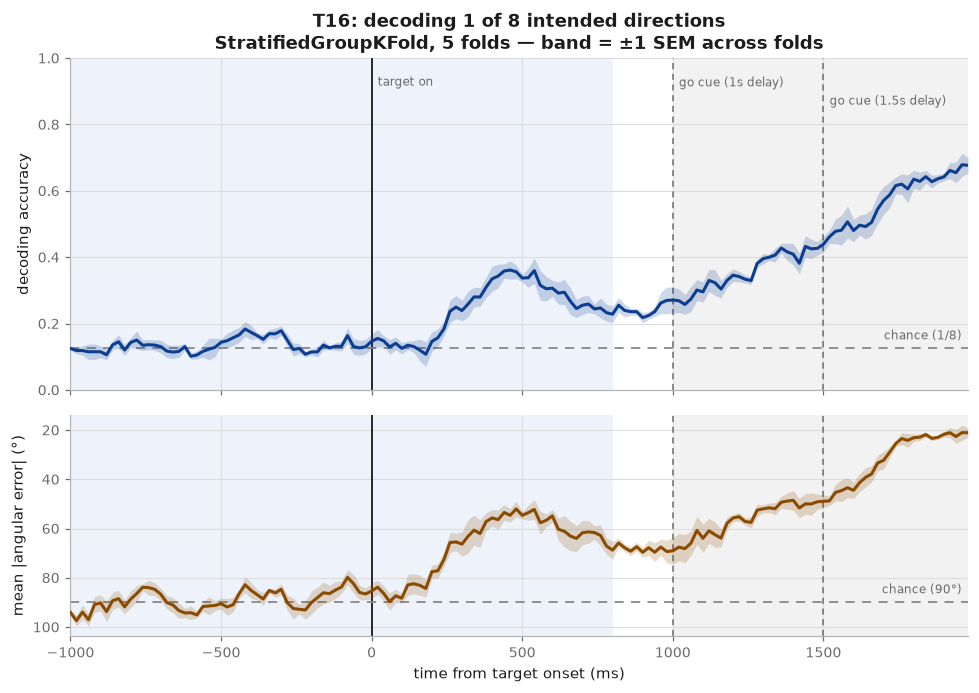

In [8]:
fig = plotting.plot_time_resolved(
    t_used, acc, config.CHANCE_LEVEL,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    angular_error=ang_err,
    chance_angle=chance_angular_error_deg(config.N_DIRECTIONS),
    title="\n".join([
        f"{config.PARTICIPANT}: decoding 1 of {config.N_DIRECTIONS} intended directions",
        f"{cv_plan.scheme}, {n_folds} folds — band = ±1 SEM across folds",
    ]),
)
fig.savefig(config.FIGURES_DIR / "time_resolved_decoding.png", bbox_inches="tight")
plt.show()

In [9]:
def window_stat(values, window):
    sel = (t_used >= window[0]) & (t_used <= window[1])
    return values[:, sel].mean(axis=1)

baseline_win = (-1000.0, -200.0)
prep_win = (300.0, 800.0)

print("Mean across folds (± SD across folds)\n")
for name, win in [("baseline (pre-target)", baseline_win),
                  ("preparatory", prep_win)]:
    a = window_stat(acc, win)
    b = window_stat(bacc, win)
    e = window_stat(ang_err, win)
    print(f"{name}  [{win[0]:.0f} to {win[1]:.0f} ms]")
    print(f"   accuracy          : {a.mean():.3f} ± {a.std(ddof=1):.3f}   "
          f"(chance {config.CHANCE_LEVEL:.3f})")
    print(f"   balanced accuracy : {b.mean():.3f} ± {b.std(ddof=1):.3f}")
    print(f"   |angular error|   : {e.mean():.1f}° ± {e.std(ddof=1):.1f}°   "
          f"(chance {chance_angular_error_deg(config.N_DIRECTIONS):.1f}°)")
    print(f"   per-fold accuracy : {np.round(a, 3).tolist()}\n")

peak_i = int(np.argmax(acc.mean(axis=0)))
print(f"peak accuracy {acc.mean(axis=0)[peak_i]:.3f} at t = {t_used[peak_i]:+.0f} ms")

prep_sel = (t_used >= config.PREP_WINDOW_MS[0]) & (t_used <= config.PREP_WINDOW_MS[1])
prep_peak_i = int(np.argmax(np.where(prep_sel, acc.mean(axis=0), -np.inf)))
print(f"peak within the preparatory window: {acc.mean(axis=0)[prep_peak_i]:.3f} "
      f"at t = {t_used[prep_peak_i]:+.0f} ms")

Mean across folds (± SD across folds)

baseline (pre-target)  [-1000 to -200 ms]
   accuracy          : 0.135 ± 0.014   (chance 0.125)
   balanced accuracy : 0.132 ± 0.012
   |angular error|   : 90.0° ± 1.9°   (chance 90.0°)
   per-fold accuracy : [0.117, 0.15, 0.144, 0.139, 0.123]

preparatory  [300 to 800 ms]
   accuracy          : 0.294 ± 0.041   (chance 0.125)
   balanced accuracy : 0.287 ± 0.047
   |angular error|   : 59.4° ± 4.5°   (chance 90.0°)
   per-fold accuracy : [0.299, 0.318, 0.255, 0.347, 0.251]

peak accuracy 0.678 at t = +1960 ms
peak within the preparatory window: 0.361 at t = +460 ms


> ### ⚠️ How to read the timing — the acausal smoothing caveat
>
> The features were smoothed **acausally** with a Gaussian of σ = 100 ms, meaning each bin
> is an average over activity roughly ±200 ms around it — including the **future**.
>
> So the moment when the accuracy curve leaves chance is **not** the moment cortex encoded
> the direction. Real activity arriving at, say, 200 ms has already been smeared backwards
> into bins near 0 ms. The apparent onset is necessarily *earlier* than the true one.
>
> The same applies at the other end: the rise approaching the go cue partly reflects
> movement-related activity leaking backwards into pre-go bins.
>
> **What we can legitimately claim:** direction is decodable well above chance during the
> delay, sustained across it, while the participant is not moving.
> **What we cannot claim:** any specific onset latency.
>
> Neighbouring points are also *not independent* — bins 20 ms apart share most of their
> smoothing window — which is why the curve looks so smooth and why per-time-point
> significance tests need the correction discussed in section 7.

## 6. Two diagnostics

### 6a. What kind of mistakes does it make?

Pool the out-of-fold predictions across the preparatory window and look at the confusion
matrix. If the population code is genuinely directional, errors should concentrate on
directions *adjacent* to the true one — a smooth structure around the diagonal — rather
than scattering uniformly.

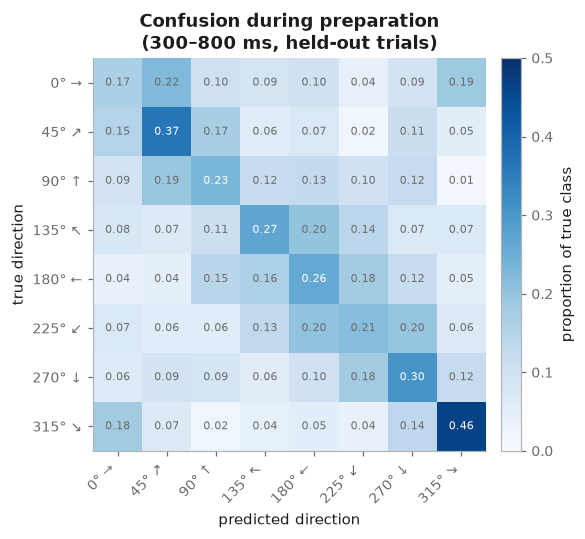

predictions   0° from the true direction: 0.285
predictions  45° from the true direction: 0.340
predictions  90° from the true direction: 0.182
predictions 135° from the true direction: 0.127
predictions 180° from the true direction: 0.066


In [10]:
prep_sel_idx = np.where((t_used >= prep_win[0]) & (t_used <= prep_win[1]))[0]
true_pooled = np.repeat(y, prep_sel_idx.size)
pred_pooled = oof_pred[:, prep_sel_idx].ravel()

cm = confusion_matrix(true_pooled, pred_pooled, labels=range(config.N_DIRECTIONS),
                      normalize="true")

fig, ax = plt.subplots(figsize=(5.8, 5.0))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=max(0.5, cm.max()))
labels_txt = [f"{int(np.degrees(a))}° {g}"
              for a, g in zip(centres, plotting.DIRECTION_ARROWS)]
ax.set_xticks(range(config.N_DIRECTIONS), labels_txt, rotation=45, ha="right")
ax.set_yticks(range(config.N_DIRECTIONS), labels_txt)
ax.set_xlabel("predicted direction")
ax.set_ylabel("true direction")
ax.set_title(f"Confusion during preparation\n({prep_win[0]:.0f}–{prep_win[1]:.0f} ms, "
             f"held-out trials)")
ax.grid(False)
for i in range(config.N_DIRECTIONS):
    for j in range(config.N_DIRECTIONS):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if cm[i, j] > 0.5 * cm.max() else plotting.INK_MUTED)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, label="proportion of true class")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "confusion_preparatory.png", bbox_inches="tight")
plt.show()

off = np.abs(np.subtract.outer(np.arange(8), np.arange(8)))
off = np.minimum(off, 8 - off)          # circular distance between classes
for d in range(5):
    print(f"predictions {d * 45:3d}° from the true direction: "
          f"{cm[off == d].sum() / cm.sum():.3f}")

### 6b. How much would normalisation leakage have inflated this?

This is the demonstration promised in section 3. We repeat the decoding at a single
preparatory time point, twice:

- **correct** — scaler fitted inside each fold, on training trials only;
- **leaky** — scaler fitted once on *all* trials before cross-validating.

Both use identical folds and an identical classifier. Only the scaler's fitting scope
differs.

In [11]:
probe_i = prep_peak_i
X_probe = X[:, time_idx[probe_i], :]
print(f"probing t = {t_used[probe_i]:+.0f} ms\n")

correct, leaky = [], []

# Leaky version: standardise the whole dataset up front, using test trials too.
X_leaked = StandardScaler().fit_transform(X_probe)

for train_idx, test_idx in cv_plan.splits:
    ok = make_pipeline(C=config.LOGREG_C, random_state=config.RANDOM_STATE)
    ok.fit(X_probe[train_idx], y[train_idx])
    correct.append(np.mean(ok.predict(X_probe[test_idx]) == y[test_idx]))

    bad = LogisticRegression(C=config.LOGREG_C, solver="lbfgs",
                             max_iter=2000, random_state=config.RANDOM_STATE)
    bad.fit(X_leaked[train_idx], y[train_idx])
    leaky.append(np.mean(bad.predict(X_leaked[test_idx]) == y[test_idx]))

print(f"scaler fitted inside each fold (correct) : {np.mean(correct):.4f}")
print(f"scaler fitted on all trials    (leaky)   : {np.mean(leaky):.4f}")
print(f"inflation from the leak                  : "
      f"{np.mean(leaky) - np.mean(correct):+.4f}")

probing t = +460 ms

scaler fitted inside each fold (correct) : 0.3613
scaler fitted on all trials    (leaky)   : 0.3567
inflation from the leak                  : -0.0045


**The result is worth being honest about: here the leak changes accuracy by well under one
percentage point, and in this run it came out slightly *negative*.** That is not a mistake
in the demonstration — it is what this particular leak is worth on this particular data.
`StandardScaler` leaks only two numbers per channel (a mean and an SD) estimated from a few
hundred trials, so the training-set and full-set constants are nearly identical, and the
difference that remains is smaller than the fold-to-fold noise.

Draw the right lesson from that, which is *not* "leakage does not matter":

- The magnitude of a leak depends entirely on **how much the leaked quantity depends on the
  test data**. Two constants per channel: negligible. But fit a **PCA**, a **feature
  selection** step, or a **hyper-parameter search** on the full dataset and the leaked
  object is shaped by the test set in ways that can inflate accuracy enormously — sometimes
  producing confident, publishable-looking results from pure noise.
- You cannot tell which case you are in by looking at the accuracy. A leak does not announce
  itself; it just returns a number that is too good, and there is no diagnostic in the
  output that distinguishes it from a real effect.

So the protection has to be **structural, not numerical**: *nothing is fitted outside the
fold loop*, regardless of whether you expect it to matter. Putting every fitted step inside
a `Pipeline` enforces that rule for free, which is why we use one even here where the
stakes turn out to be low.

## 7. Optional: a permutation test

Chance is 12.5% *in theory*. A permutation test measures what this decoder, on this
dataset, with these folds, actually achieves when the labels carry no information — which
accounts for finite trial counts, class imbalance and fold structure all at once.

Two details matter:

- **Permute within block.** A global shuffle would destroy the direction↔block association
  as well as the direction↔activity one, making the null too easy to beat and our result
  look better than it is.
- **Use a max-statistic.** We test 150 time points. Testing each independently at p < 0.05
  would produce false positives by construction. So on each permutation we record the
  *maximum* accuracy across all time points; the 95th percentile of that distribution is a
  single threshold that controls the family-wise error rate across the whole time course.

This is off by default (`RUN_PERMUTATIONS = False`) as it takes a few minutes.

In [12]:
perm_threshold = None
if config.RUN_PERMUTATIONS:
    rng = np.random.default_rng(config.RANDOM_STATE)
    null_max = np.zeros(config.N_PERMUTATIONS)

    for p in range(config.N_PERMUTATIONS):
        y_perm = permute_labels_within_blocks(y, blocks, rng)
        perm_acc = np.zeros(n_times)
        for ti, bin_idx in enumerate(time_idx):
            X_t = X[:, bin_idx, :]
            fold_acc = []
            for train_idx, test_idx in cv_plan.splits:
                m = make_pipeline(C=config.LOGREG_C, random_state=config.RANDOM_STATE)
                m.fit(X_t[train_idx], y_perm[train_idx])
                fold_acc.append(np.mean(m.predict(X_t[test_idx]) == y_perm[test_idx]))
            perm_acc[ti] = np.mean(fold_acc)
        null_max[p] = perm_acc.max()
        if (p + 1) % 20 == 0:
            print(f"  permutation {p + 1}/{config.N_PERMUTATIONS}")

    perm_threshold = float(np.percentile(null_max, 95))
    print(f"\nmax-statistic null: mean {null_max.mean():.3f}, "
          f"95th percentile {perm_threshold:.3f}")
    print(f"observed peak accuracy: {acc.mean(axis=0).max():.3f}")
    np.save(config.TABLES_DIR / "permutation_null_max.npy", null_max)
else:
    print("RUN_PERMUTATIONS is False - skipped.")
    print("Set it to True in config.py to estimate the empirical null "
          "(a few minutes).")

RUN_PERMUTATIONS is False - skipped.
Set it to True in config.py to estimate the empirical null (a few minutes).


## 8. Save the results

Long format, one row per (time bin × fold), so fold-level performance stays inspectable
rather than being averaged away. The CV scheme is stored in every row — a result should
always carry the method that produced it.

We also save the folds themselves, so notebook 04 can verify it is using exactly the same
splits rather than merely a similar-looking reshuffle.

In [13]:
rows = []
for fi in range(n_folds):
    for ti in range(n_times):
        rows.append({
            "t_ms": t_used[ti],
            "fold": fi,
            "accuracy": acc[fi, ti],
            "balanced_accuracy": bacc[fi, ti],
            "mean_abs_angular_error_deg": ang_err[fi, ti],
            "cv_scheme": cv_plan.scheme,
            "participant": config.PARTICIPANT,
            "feature_type": config.FEATURE_TYPE,
        })
results = pd.DataFrame(rows)
out_csv = config.TABLES_DIR / "time_resolved_decoding.csv"
results.to_csv(out_csv, index=False)
print(f"saved -> {out_csv}   ({len(results)} rows)")

np.savez(
    config.TABLES_DIR / "oof_predictions.npz",
    oof_pred=oof_pred, y=y, blocks=blocks, t_ms=t_used, time_idx=time_idx,
)
print(f"saved -> {config.TABLES_DIR / 'oof_predictions.npz'}")

# The exact folds, plus a fingerprint of the trial set they were built for.
# crc32, not hash(): Python randomises hash() of bytes per process, so it would
# differ between this notebook and notebook 04 and the check would never pass.
trial_fingerprint = zlib.crc32(keep.tobytes())
np.savez(
    config.TABLES_DIR / "cv_splits.npz",
    **{f"train_{i}": tr for i, (tr, te) in enumerate(cv_plan.splits)},
    **{f"test_{i}": te for i, (tr, te) in enumerate(cv_plan.splits)},
    n_splits=cv_plan.n_splits, scheme=cv_plan.scheme,
    trial_fingerprint=trial_fingerprint, keep_mask=keep,
)
print(f"saved -> {config.TABLES_DIR / 'cv_splits.npz'}  "
      f"(fingerprint {trial_fingerprint})")

results.groupby("fold")["accuracy"].describe().round(3)

saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\time_resolved_decoding.csv   (750 rows)
saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\oof_predictions.npz
saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\cv_splits.npz  (fingerprint 1884526301)


,count,mean,std,min,25%,50%,75%,max
fold,,,,,,,,
0,150.0,0.266,0.164,0.057,0.136,0.216,0.375,0.670
1,150.0,0.287,0.164,0.068,0.159,0.250,0.381,0.727
2,150.0,0.280,0.173,0.047,0.145,0.233,0.372,0.744
3,150.0,0.291,0.166,0.073,0.146,0.244,0.415,0.756
4,150.0,0.277,0.183,0.042,0.125,0.229,0.349,0.708


## What we established

*(The numbers below are from the T16 run committed with this notebook; re-running with
different settings will move them.)*

**Q1 — is direction information present before movement? Yes.**

| window | accuracy | angular error |
|---|---|---|
| baseline, −1000 to −200 ms | **0.135** (chance 0.125) | 90.0° (chance 90.0°) |
| preparatory, 300 to 800 ms | **0.294** — 2.4× chance | 59.4° |
| peak within the delay | **0.361** at t = +460 ms | — |
| peak overall (during movement) | 0.678 at t = +1960 ms | — |

The pre-target baseline is the analysis's own negative control, and it behaves: accuracy
sits within a hair of 12.5% and the angular error is exactly 90.0°, the chance value.
Because the folds are grouped by recording block, the preparatory result generalises to
blocks the decoder never saw — it is not block-specific drift. And because a *linear*
decoder finds it, the information is linearly available, the form a practical BCI could use.

One honest caveat on that baseline: 0.135 is marginally above the nominal 0.125, and
balanced accuracy (0.132) is too. With ~264 trials and slightly unequal class counts this is
well within what finite samples produce, but it is a reminder that "12.5%" is a theoretical
value. The permutation test in section 7 exists precisely to replace it with an empirical one.

**Q2 — when is it expressed?** Two features stand out, and the second is easy to miss:

- Information rises steeply after target onset — but we make **no claim about the onset
  latency**. With acausal σ = 100 ms smoothing, the apparent onset is necessarily earlier
  than the true one.
- Decoding does **not** simply plateau. It peaks around +460 ms (≈0.36) and then *declines*
  through the rest of the delay, down to roughly 0.22 by 900 ms, before rising again once
  movement begins. So directional information is strongest shortly after the target is
  revealed and is then held at a lower, sustained level while the participant waits. The
  early transient plausibly mixes the visual response to the target with the initial setting
  of the preparatory state; the sustained plateau is the part most cleanly attributable to
  maintained preparation. Either way, information stays clearly above chance across the
  entire delay.

The confusion matrix adds something accuracy alone cannot. Errors are not scattered: 34.0%
of predictions land on a direction **adjacent** to the true one (45° away) — more often
than the exactly-correct 28.5% — while only 6.6% land on the **opposite** direction. The
decoder's mistakes respect the circular geometry of the task, which is what you expect from
a genuine directional code and not from eight arbitrary labels. This is also why the angular
error panel tells a slightly more favourable story than accuracy does: 59.4° of mean error
during preparation, against 90° for guessing.

**What this does not yet tell us.** Whether the population code is *the same code*
throughout the delay. A sustained accuracy curve is equally consistent with one stable
pattern held steady, and with a pattern that continuously morphs while remaining
decodable at every instant. Distinguishing those is notebook 04.

---

## Now try this

1. **Break the CV on purpose.** Replace `cv_plan` with a plain
   `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` and re-run the sweep.
   Does accuracy go up? Any increase is the block-drift shortcut being exploited — and it
   is why the grouped scheme is the honest default.
2. **Change the regularisation.** Try `LOGREG_C = 0.01` and `LOGREG_C = 100`. Which end
   hurts more, and what does that tell you about how many of the 61 channels carry usable
   directional information?
3. **Swap the feature.** Set `FEATURE_TYPE = "sbp"`, then `"spikes+sbp"`. Does spike-band
   power add anything beyond threshold crossings, or is it largely redundant?
4. **Run the no-go control.** Set `GO_TRIALS_ONLY = False` and re-run. On no-go trials the
   movement is never released, so the whole epoch stays preparatory. Does decoding persist
   past 1000 ms on those trials? This is a strong check that the delay-period result is not
   contaminated by early movement.
5. **Turn on the permutation test.** Set `RUN_PERMUTATIONS = True`. Where does the
   max-statistic threshold fall relative to 12.5%, and relative to your observed peak?